In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu

In [2]:
sample_table = pd.read_csv("../data_processed/sample_table.csv", index_col=0)

groups  = ["surface", "subsurface"]
colors  = {"surface": "#c2e8e5ff", "subsurface": "#ad8b56ff"}

pathway_cols   = ["mean_cbb_1", "mean_rtca_1", "mean_wl_1", "mean_hp_1", "mean_hphb_1", "mean_dchb_1"]
pathway_labels = ["CBB", "rTCA", "WL", "3HP", "HPHB", "DCHB"]

Sequencing depth surface vs subsurface (full dataset)

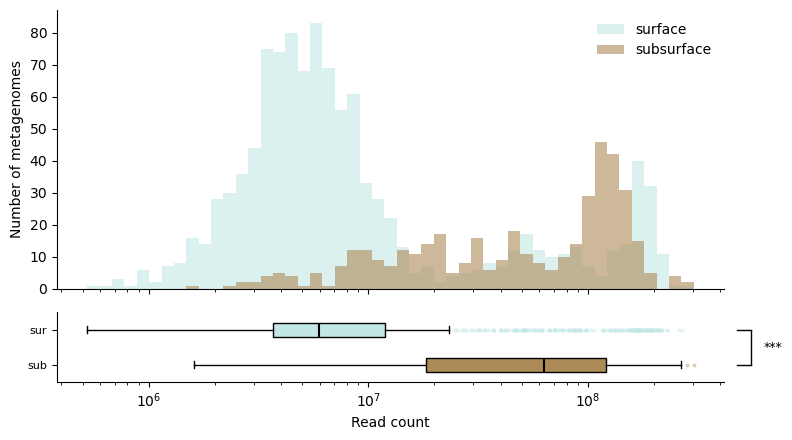

In [3]:
bins = np.logspace(np.log10(sample_table["readcount"].dropna().min()),
                   np.log10(sample_table["readcount"].dropna().max()), 50)

_, p_a = mannwhitneyu(
    sample_table.loc[sample_table["surface_subsurface"] == "surface",    "readcount"].dropna(),
    sample_table.loc[sample_table["surface_subsurface"] == "subsurface", "readcount"].dropna(),
    alternative="two-sided"
)
s_a = "***" if p_a < 0.001 else ("**" if p_a < 0.01 else ("*" if p_a < 0.05 else "ns"))

fig, (ax_hist, ax_box) = plt.subplots(2, 1, figsize=(8, 4.5), sharex=True,
                                       gridspec_kw={"height_ratios": [4, 1]})
for g in groups:
    ax_hist.hist(sample_table.loc[sample_table["surface_subsurface"] == g, "readcount"].dropna(),
                 bins=bins, alpha=0.6, color=colors[g], edgecolor="none", label=g)
ax_hist.set_xscale("log")
ax_hist.set_ylabel("Number of metagenomes")
ax_hist.legend(frameon=False)
ax_hist.spines[["top", "right"]].set_visible(False)

bp = ax_box.boxplot(
    [sample_table.loc[sample_table["surface_subsurface"] == g, "readcount"].dropna() for g in groups],
    positions=[1, 0], vert=False, patch_artist=True, widths=0.4,
    medianprops=dict(color="black", linewidth=1.5),
    flierprops=dict(marker="o", markersize=2, alpha=0.3, linestyle="none"),
)
for patch, g in zip(bp["boxes"], groups):
    patch.set_facecolor(colors[g])
    patch.set_edgecolor("black")
for flier, g in zip(bp["fliers"], groups):
    flier.set_markerfacecolor(colors[g])
    flier.set_markeredgecolor(colors[g])
ax_box.set_xlabel("Read count")
ax_box.set_yticks([0, 1])
ax_box.set_yticklabels(["sub", "sur"], fontsize=8)
ax_box.spines[["top", "right"]].set_visible(False)

# significance bracket between the two boxplots
t = ax_box.get_yaxis_transform()
ax_box.plot([1.04, 1.04], [0, 1], transform=t, color="black", linewidth=1, clip_on=False)
ax_box.plot([1.02, 1.04], [0, 0], transform=t, color="black", linewidth=1, clip_on=False)
ax_box.plot([1.02, 1.04], [1, 1], transform=t, color="black", linewidth=1, clip_on=False)
ax_box.text(1.06, 0.5, s_a, transform=t, ha="left", va="center", fontsize=9, clip_on=False)

plt.tight_layout()
plt.savefig("../outputs/readcount_distributions_all.svg", format="svg", transparent=True)
plt.show()

Now we select depth-matched pairs

In [4]:
# 1:1 nearest-neighbour matching on log(readcount), caliper = 0.2 log10 units (max 1.6x ratio)
sub_all  = sample_table.dropna(subset=["readcount"])[sample_table["surface_subsurface"] == "subsurface"]
surf_all = sample_table.dropna(subset=["readcount"])[sample_table["surface_subsurface"] == "surface"]

surf_pool = surf_all.copy()
matched_surf, matched_sub = [], []

for idx, rc in sub_all["readcount"].items():
    dists = np.abs(np.log10(surf_pool["readcount"]) - np.log10(rc))
    if dists.min() <= 0.2:
        best = dists.idxmin()
        matched_surf.append(best)
        matched_sub.append(idx)
        surf_pool = surf_pool.drop(index=best)

matched = pd.concat([surf_all.loc[matched_surf], sub_all.loc[matched_sub]])
print(f'{len(matched_sub)} pairs selected')

343 pairs selected


We check that the read counts are about the same

0.26


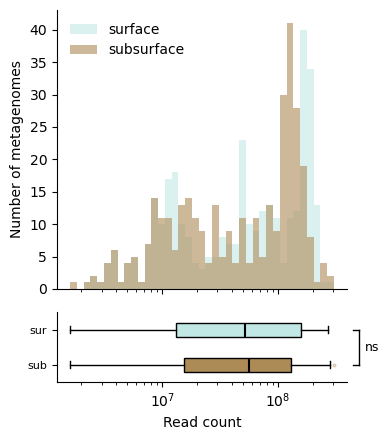

In [5]:
bins_m = np.logspace(np.log10(matched["readcount"].min()),
                     np.log10(matched["readcount"].max()), 40)

_, p_depth = mannwhitneyu(
    matched.loc[matched["surface_subsurface"] == "surface",    "readcount"],
    matched.loc[matched["surface_subsurface"] == "subsurface", "readcount"],
    alternative="two-sided"
)
s_b = "***" if p_depth < 0.001 else ("**" if p_depth < 0.01 else ("*" if p_depth < 0.05 else "ns"))

fig, (ax_hist, ax_box) = plt.subplots(2, 1, figsize=(4, 4.5), sharex=True,
                                       gridspec_kw={"height_ratios": [4, 1]})
for g in groups:
    ax_hist.hist(matched.loc[matched["surface_subsurface"] == g, "readcount"].dropna(),
                 bins=bins_m, alpha=0.6, color=colors[g], edgecolor="none", label=g)
ax_hist.set_xscale("log")
ax_hist.set_ylabel("Number of metagenomes")
ax_hist.legend(frameon=False)
ax_hist.spines[["top", "right"]].set_visible(False)

bp = ax_box.boxplot(
    [matched.loc[matched["surface_subsurface"] == g, "readcount"].dropna() for g in groups],
    positions=[1, 0], vert=False, patch_artist=True, widths=0.4,
    medianprops=dict(color="black", linewidth=1.5),
    flierprops=dict(marker="o", markersize=2, alpha=0.3, linestyle="none"),
)
for patch, g in zip(bp["boxes"], groups):
    patch.set_facecolor(colors[g])
    patch.set_edgecolor("black")
for flier, g in zip(bp["fliers"], groups):
    flier.set_markerfacecolor(colors[g])
    flier.set_markeredgecolor(colors[g])
ax_box.set_xlabel("Read count")
ax_box.set_yticks([0, 1])
ax_box.set_yticklabels(["sub", "sur"], fontsize=8)
ax_box.spines[["top", "right"]].set_visible(False)

# significance bracket between the two boxplots
t = ax_box.get_yaxis_transform()
ax_box.plot([1.04, 1.04], [0, 1], transform=t, color="black", linewidth=1, clip_on=False)
ax_box.plot([1.02, 1.04], [0, 0], transform=t, color="black", linewidth=1, clip_on=False)
ax_box.plot([1.02, 1.04], [1, 1], transform=t, color="black", linewidth=1, clip_on=False)
ax_box.text(1.06, 0.5, s_b, transform=t, ha="left", va="center", fontsize=9, clip_on=False)

print(f'{p_depth:.2f}')
plt.tight_layout()
plt.savefig("../outputs/readcount_distributions_matched_depth_selection.svg", format="svg", transparent=True)
plt.show()


CFP abundance on depth-matched samples only

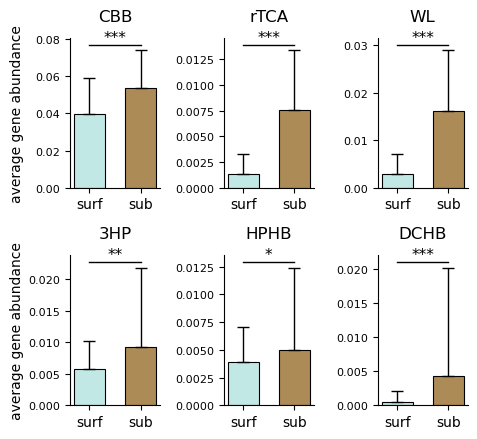

In [6]:
def star(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

fig, axes = plt.subplots(2, 3, figsize=(5, 4.5), sharey=False)
axes = axes.flatten()

for ax, col, label in zip(axes, pathway_cols, pathway_labels):
    for gi, g in enumerate(groups):
        vals = matched.loc[matched["surface_subsurface"] == g, col].dropna()
        ax.bar(gi, vals.mean(), yerr=[[0], [vals.std()]], color=colors[g], edgecolor="black",
               linewidth=0.8, capsize=4, width=0.6, error_kw=dict(linewidth=1))

    _, p = mannwhitneyu(
        matched.loc[matched["surface_subsurface"] == "surface",    col].dropna(),
        matched.loc[matched["surface_subsurface"] == "subsurface", col].dropna(),
        alternative="two-sided"
    )

    y_max = max(matched.loc[matched["surface_subsurface"] == g, col].dropna().mean()
                + matched.loc[matched["surface_subsurface"] == g, col].dropna().std()
                for g in groups)

    ax.plot([0, 1], [y_max * 1.04, y_max * 1.04], color="black", linewidth=1)
    ax.text(0.5, y_max * 1.04, star(p), ha="center", va="bottom", fontsize=11)

    ax.set_title(label)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["surf", "sub"], fontsize=10)
    ax.set_ylim(bottom=0)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis='y', labelsize=8)  # smaller y-axis numbers
    ax.set_title(label, pad=12)  # increase distance from plot

axes[0].set_ylabel("average gene abundance")
axes[3].set_ylabel("average gene abundance")
axes[0].yaxis.set_label_coords(-0.51, 0.5)
axes[3].yaxis.set_label_coords(-0.51, 0.5)

plt.tight_layout()
plt.savefig("../outputs/CFP_abundance_matched_depth_selection.svg", format="svg", transparent=True)
plt.show()